In [1]:
! pip install openai

In [91]:
import matplotlib.pyplot as plt

In [39]:
import sys
from getpass import getpass
import os

sys.path.append("./modules")
from OpenRouter import OpenRouterInference

In [115]:
from IPython.display import Image as IPyImage, display

In [33]:
api=getpass.getpass(prompt="YOUR API KEY: ")

YOUR API KEY:  ········


In [63]:
llm = OpenRouterInference(
    api_key=api, 
    model='minimax/minimax-m3:free'
)

In [65]:
llm.generate("Ты справишься с OCR задачей с этикеток вина?")

'Да, я могу помочь с распознаванием текста с этикеток вина! Вот что я могу сделать:\n\n**Что я умею:**\n- Извлекать текст с изображений этикеток\n- Распознавать названия вин, производителей, регионов, урожаев\n- Считывать информацию о сортах винограда, крепости, объёме\n- Определять классификации (DOC, DOCG, AOC и т.д.)\n- Читать текст на разных языках (включая кириллицу, латиницу, грузинский армянский и др.)\n\n**Как лучше работать:**\n1. 📷 Пришлите чёткое фото этикетки\n2. 🔍 Если текст плохо читается на фото — укажите, какой фрагмент нужно распознать\n3. 🌐 Сообщите язык, если он не очевиден\n\n**Примеры задач, с которыми могу помочь:**\n- Перевод текста с этикетки\n- Систематизация данных о вине (название, год, регион)\n- Анализ информации на контрэтикетке\n\nПрисылайте изображение — постараюсь помочь! 🍷'

In [79]:
from BottleCropper import BottleCropper

cropper = BottleCropper(model_path='./models/best_yolo26s.pt', bottle_class_id=0, conf_thresh=0.25)

INFO:BottleCropper:Загружаем модель: ./models/best_yolo26s.pt


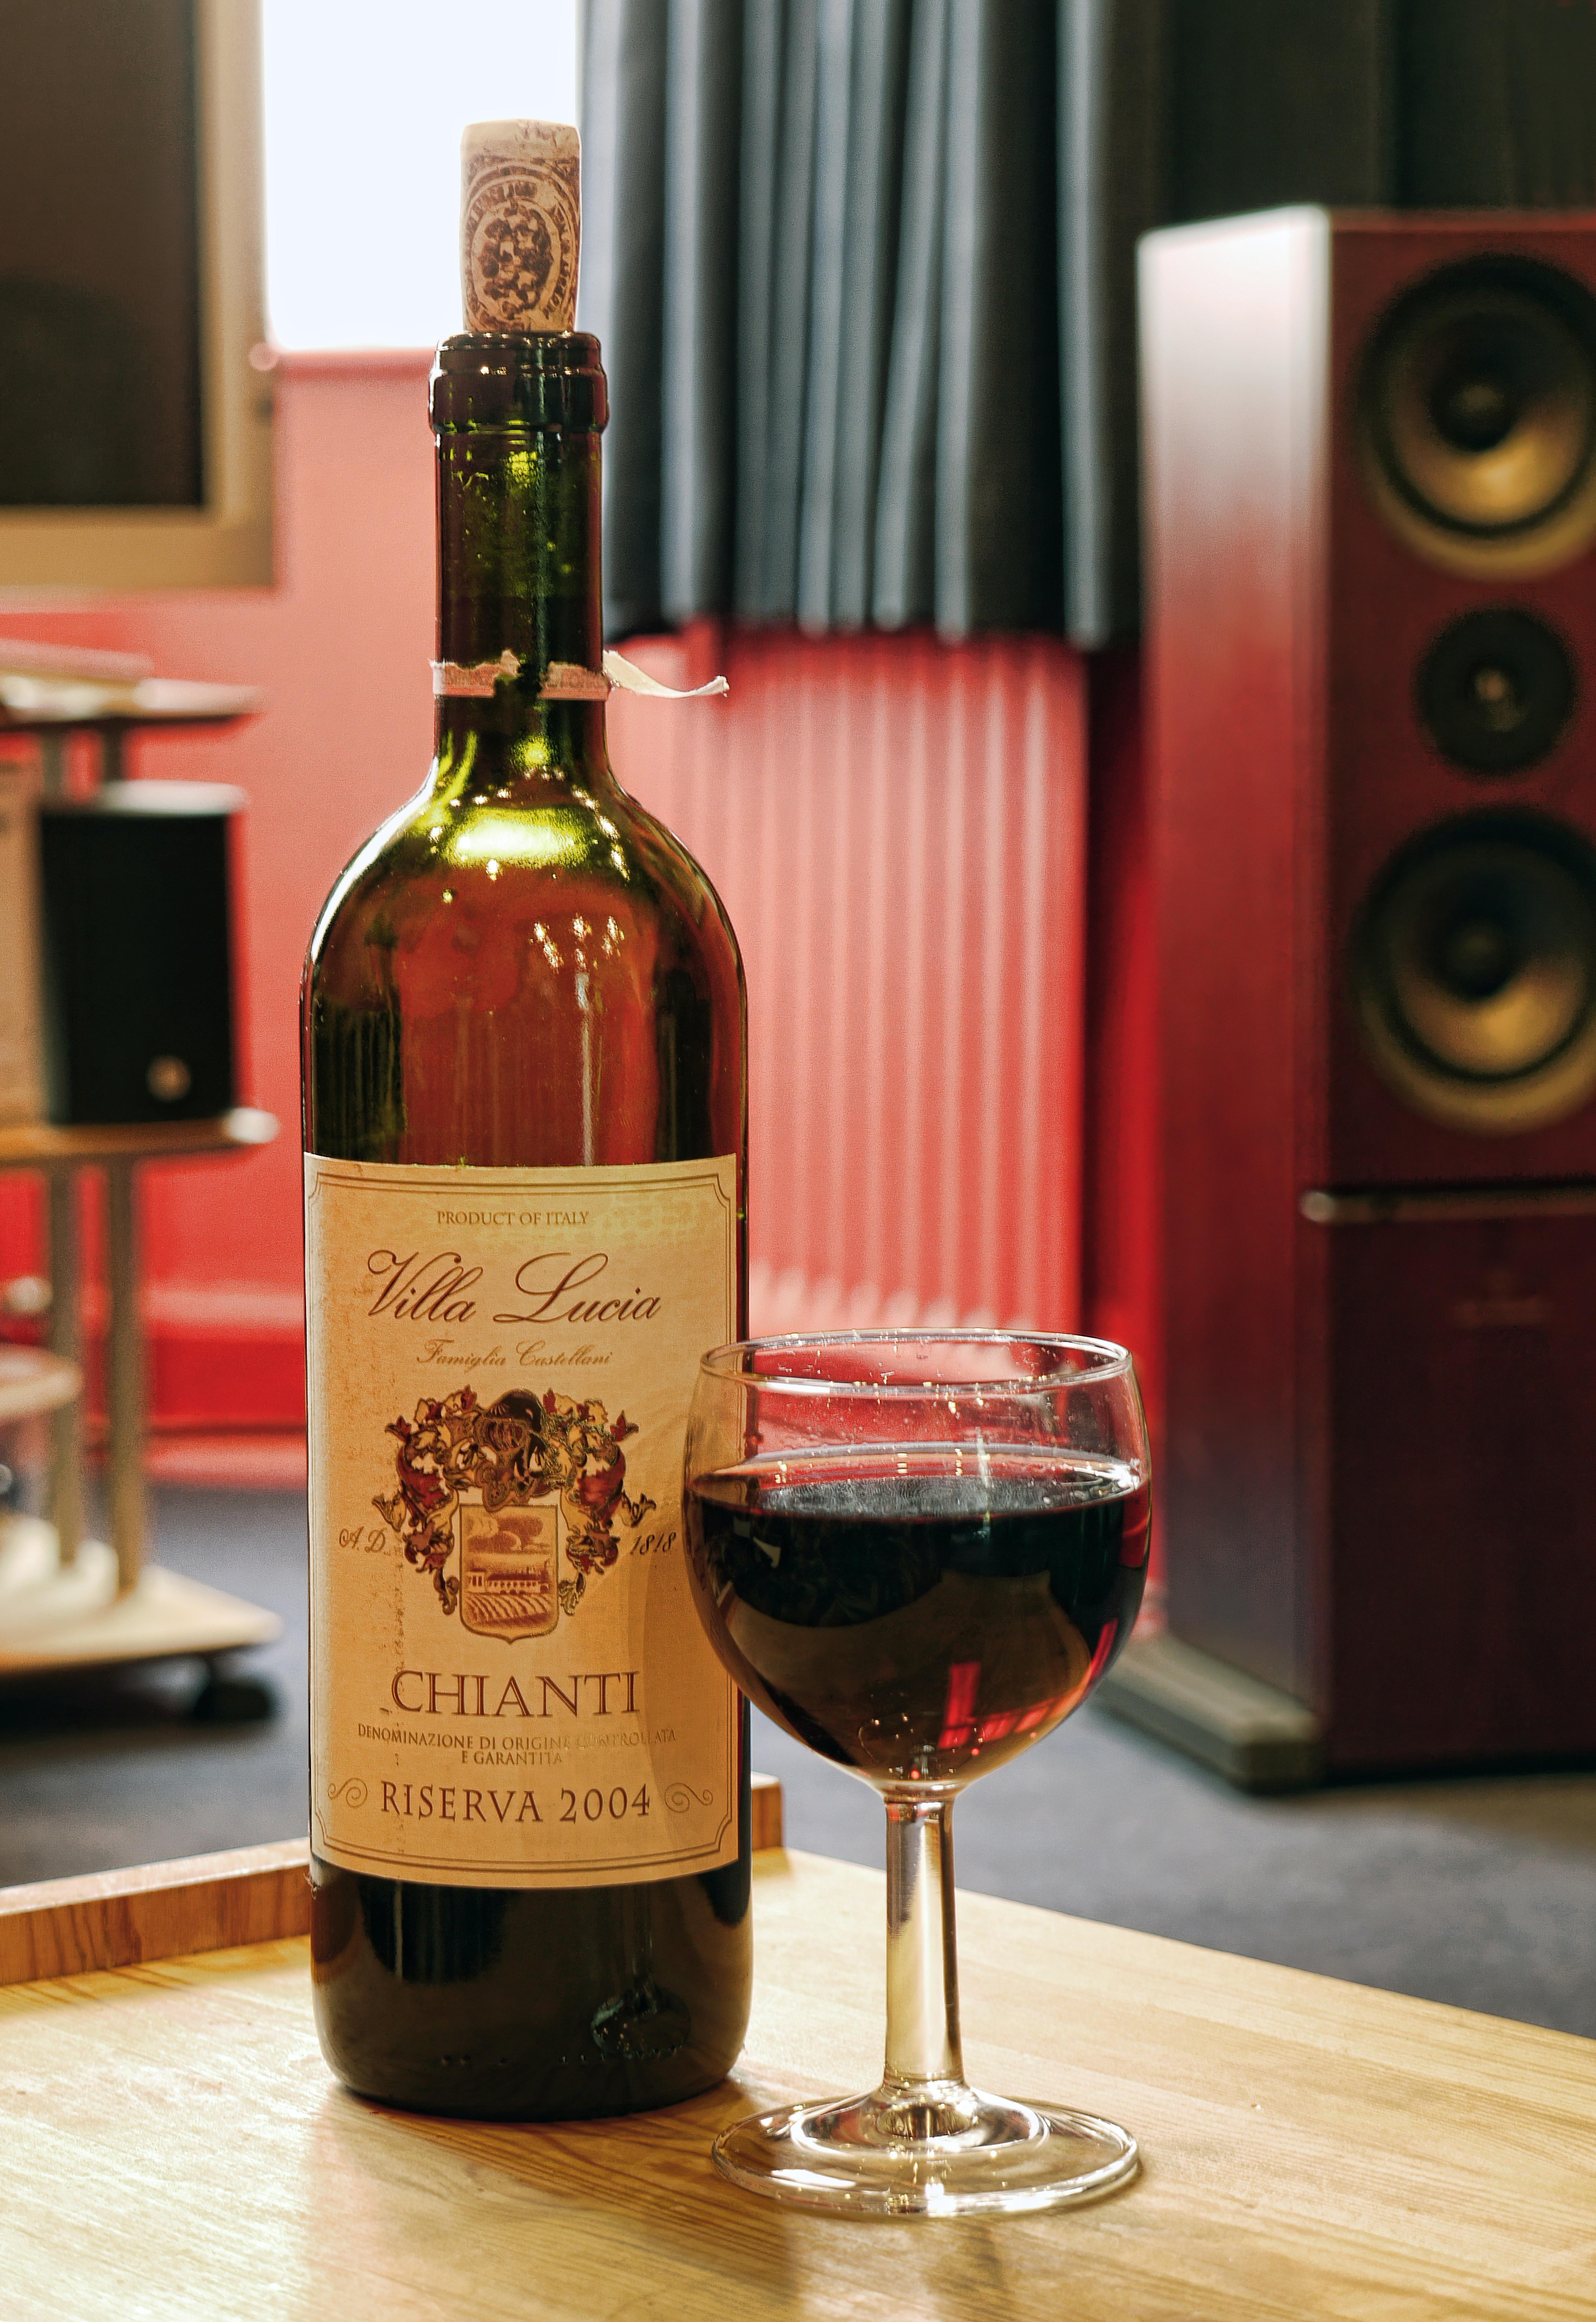

In [119]:
image = os.listdir("./dataset/test/images/")[6]
display(IPyImage(os.path.join("./dataset/test/images/", image)))

INFO:BottleCropper:Вырезана самая большая бутылка: 'Wine_Botle', уверенность 92.70%, площадь 10935162 px²


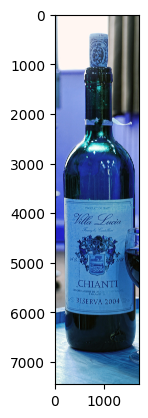

In [121]:
bottle = cropper.crop_image(os.path.join("./dataset/test/images/", image))
plt.imshow(bottle[0])

In [137]:
SYSTEM_PROMPT_OCR = (
    "Ты — высокоточный движок оптического распознавания символов (OCR). "
    "Твоя задача — извлекать структурированную информацию из этикетки вина "
    "Отвечай СТРОГО в формате валидного JSON. "
    "Ты должен извлекать ключевую информацию о вине: label: название вина - str"
    "dry: количество сахара (сухое, полусухое, полусладкие, сладкое) - str, color: цвет (красное, розовое, белое) str, region: регион - str, "
    "grapes: сорта винограда - list[str], year: год изготовления - str. "
    "Не добавляй никаких пояснений до или после JSON. "
    "Не ставь метки формата данных. Только сам словарь "
    "Ты должен вставлять ключевую информация строго из текста"
    # "Твоя единственная задача — дословно, буква в букву, считывать весь видимый текст с изображения. "
    "СТРОГО ЗАПРЕЩЕНО: добавлять комментарии, исправлять ошибки, интерпретировать текст, "
    # "добавлять приветствия или пояснения. Выводи ТОЛЬКО сырой текст с картинки, "
    # "сохраняя оригинальный регистр, переносы строк и пунктуацию."
)

USER_PROMPT_OCR = "Буквально считай весь текст с этикетки этой бутылки. Возьми сорта винограда, регион, цыет вина, сухость вина, год."

In [139]:
from PIL import Image

In [145]:
ocr_raw = llm.generate(
    system_prompt=SYSTEM_PROMPT_OCR,
    user_prompt=USER_PROMPT_OCR,
    image_input=Image.fromarray(bottle[0])
)
ocr_raw

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


'{"label": "Villa Lucia Chianti Riserva", "dry": "сухое", "color": "красное", "region": "Chianti", "grapes": ["Sangiovese"], "year": "2004"}'

In [146]:
import json

data = json.loads(ocr_raw)
data

{'label': 'Villa Lucia Chianti Riserva',
 'dry': 'сухое',
 'color': 'красное',
 'region': 'Chianti',
 'grapes': ['Sangiovese'],
 'year': '2004'}